# 04 — Classification Avancée
**Projet LendingClub | Membre 2**

| Étape | Contenu |
|---|---|
| 1 | Chargement pipeline + données (Membre 1) |
| 2 | Baseline — Régression Logistique |
| 3 | LightGBM (GPU si disponible) |
| 4 | CatBoost |
| 5 | Random Forest |
| 6 | Stacking Ensemble |
| 7 | Calibration des probabilités |
| 8 | Tableau comparatif + sélection du meilleur modèle |

---
> **Prérequis :** `03_pipeline.ipynb` doit avoir été exécuté (fichiers dans `../data/processed/`)

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, json, time, joblib
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, StackingClassifier
from sklearn.calibration     import CalibratedClassifierCV, calibration_curve
from sklearn.metrics         import (
    roc_auc_score, average_precision_score, f1_score,
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, brier_score_loss
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

import lightgbm as lgb
from catboost import CatBoostClassifier

PROCESSED = "../data/processed"
MODELS    = "../data/models"
os.makedirs(MODELS, exist_ok=True)

# ── Détection GPU ───────────────────────────────────────────────────
import subprocess
try:
    result = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total",
                             "--format=csv,noheader"], capture_output=True, text=True)
    GPU_NAME = result.stdout.strip()
    GPU_AVAILABLE = len(GPU_NAME) > 0
except FileNotFoundError:
    GPU_AVAILABLE = False
    GPU_NAME = "Non détecté"

LGBM_GPU_PARAMS = {"device": "gpu", "gpu_platform_id": 0, "gpu_device_id": 0} if GPU_AVAILABLE \n                  else {"device": "cpu"}
XGBOOST_GPU_PARAMS = {"device": "cuda", "tree_method": "hist"} if GPU_AVAILABLE \n                     else {"device": "cpu", "tree_method": "hist"}

print(f"✅ Imports OK")
print(f"🎮 GPU : {GPU_NAME if GPU_AVAILABLE else chr(9888)+" Non disponible — CPU sera utilisé"}")
print(f"   LGBM_GPU_PARAMS    : {LGBM_GPU_PARAMS}")
print(f"   XGBOOST_GPU_PARAMS : {XGBOOST_GPU_PARAMS}")


✅ Imports OK


## 1. Chargement des données et du pipeline (Membre 1)

In [2]:
import pyarrow.parquet as pq

pq.read_table(f'{PROCESSED}/X_train.parquet')

pyarrow.Table
loan_amnt: double
funded_amnt: double
term: double
int_rate: double
installment: double
grade: large_string
sub_grade: large_string
emp_length: double
annual_inc: double
pymnt_plan: large_string
dti: double
delinq_2yrs: double
fico_range_low: double
fico_range_high: double
inq_last_6mths: double
open_acc: double
pub_rec: double
revol_bal: double
revol_util: double
total_acc: double
collections_12_mths_ex_med: double
acc_now_delinq: double
tot_coll_amt: double
tot_cur_bal: double
total_rev_hi_lim: double
acc_open_past_24mths: double
avg_cur_bal: double
bc_open_to_buy: double
bc_util: double
chargeoff_within_12_mths: double
delinq_amnt: double
mo_sin_old_il_acct: double
mo_sin_old_rev_tl_op: double
mo_sin_rcnt_rev_tl_op: double
mo_sin_rcnt_tl: double
mort_acc: double
mths_since_recent_bc: double
mths_since_recent_inq: double
num_accts_ever_120_pd: double
num_actv_bc_tl: double
num_actv_rev_tl: double
num_bc_sats: double
num_bc_tl: double
num_il_tl: double
num_op_rev_tl: dou

In [3]:
# Chargement des splits produits par le Membre 1
X_train = pd.read_parquet(f'{PROCESSED}/X_train.parquet')
X_test  = pd.read_parquet(f'{PROCESSED}/X_test.parquet')
y_train = pd.read_parquet(f'{PROCESSED}/y_train.parquet').squeeze()
y_test  = pd.read_parquet(f'{PROCESSED}/y_test.parquet').squeeze()

# Chargement des paramètres GPU
with open(f'{PROCESSED}/feature_info.json') as f:
    info = json.load(f)

USE_GPU          = info['use_gpu']
LGBM_GPU_PARAMS  = info['lgbm_gpu_params']

# Chargement du preprocessor sklearn
try:
    preprocessor = joblib.load(f'{PROCESSED}/preprocessor.pkl')
    print("✅ Preprocessor chargé")
except Exception as e:
    print(f"Erreur chargement preprocessor: {e}")
    print("Recréation du preprocessor...")
    
    # Load data
    df = pd.read_csv(f'{PROCESSED}/lending_features.csv')
    X = df.drop('target', axis=1)
    y = df['target']
    
    from sklearn.model_selection import train_test_split
    X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Create preprocessor
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler, OrdinalEncoder
    from sklearn.impute import SimpleImputer
    
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder())
    ])
    
    preprocessor = ColumnTransformer([
        ('num', num_pipeline, info['num_features']),
        ('cat', cat_pipeline, info['cat_features'])
    ])
    
    preprocessor.fit(X_train_orig)
    joblib.dump(preprocessor, f'{PROCESSED}/preprocessor.pkl')
    print("✅ Preprocessor recréé et sauvegardé")

print(f'✅ X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'   Taux défaut train : {y_train.mean()*100:.1f}%  |  test : {y_test.mean()*100:.1f}%')
print(f'   GPU disponible    : {USE_GPU}')

✅ Preprocessor chargé
✅ X_train : (1076248, 118)  |  X_test : (269062, 118)
   Taux défaut train : 20.0%  |  test : 20.0%
   GPU disponible    : True


In [4]:
# Transformation via le pipeline du Membre 1
# IMPORTANT : on transforme ici pour avoir des arrays numpy
# Le modèle sera sauvegardé avec le nombre exact de features produit par ce preprocessor
print("⏳ Transformation des données via preprocessor ...")
t0 = time.time()

X_train_t = preprocessor.transform(X_train)
X_test_t  = preprocessor.transform(X_test)

# Sauvegarder le nombre de features pour que les autres notebooks soient cohérents
N_FEATURES_PREPROCESSED = X_train_t.shape[1]
info["n_features_preprocessed"] = int(N_FEATURES_PREPROCESSED)
with open(f"{PROCESSED}/feature_info.json", "w") as fj:
    json.dump(info, fj, indent=2)

print(f"✅ Transformation terminée en {time.time()-t0:.1f}s")
print(f"   X_train_t : {X_train_t.shape}  |  NaN : {np.isnan(X_train_t).sum()}")
print(f"   X_test_t  : {X_test_t.shape}   |  NaN : {np.isnan(X_test_t).sum()}")
print(f"   n_features_preprocessed={N_FEATURES_PREPROCESSED} sauvegardé dans feature_info.json")


⏳ Transformation des données via preprocessor ...
✅ Transformation terminée en 0.0s
   X_train_t : (1076248, 118)  |  NaN : 849
   X_test_t  : (269062, 118)   |  NaN : 234


In [5]:
# Dictionnaire pour stocker les résultats de tous les modèles
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, fit=True):
    """Entraîne (si fit=True) et évalue un modèle. Retourne un dict de métriques."""
    if fit:
        t0 = time.time()
        model.fit(X_tr, y_tr)
        elapsed = time.time() - t0
    else:
        elapsed = 0

    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred  = model.predict(X_te)

    metrics = {
        'AUC-ROC'  : roc_auc_score(y_te, y_proba),
        'AUC-PR'   : average_precision_score(y_te, y_proba),
        'F1'       : f1_score(y_te, y_pred),
        'Brier'    : brier_score_loss(y_te, y_proba),
        'Temps(s)' : round(elapsed, 1),
        'model'    : model,
        'y_proba'  : y_proba,
    }
    results[name] = metrics
    print(f'  [{name:<30}]  AUC-ROC={metrics["AUC-ROC"]:.4f}  AUC-PR={metrics["AUC-PR"]:.4f}  F1={metrics["F1"]:.4f}  Brier={metrics["Brier"]:.4f}  ({elapsed:.0f}s)')
    return metrics

## 2. Baseline — Régression Logistique (référence du cours)

In [8]:
print('⏳ Baseline — Régression Logistique ...')
"""lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # compense le déséquilibre 80/20
    C=0.1,                    # régularisation L2 modérée
    solver='lbfgs',
    n_jobs=-1,
    random_state=42
)"""
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Colonnes
cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(include='number').columns

# Pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))  # remplace NaN par médiane
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # remplace NaN par valeur la plus fréquente
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocessor complet
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Transformation
X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)

# Modèle
evaluate_model('Logistic Regression (baseline)', lr, X_train_t, y_train, X_test_t, y_test)

⏳ Baseline — Régression Logistique ...
  [Logistic Regression (baseline)]  AUC-ROC=0.7008  AUC-PR=0.3575  F1=0.4224  Brier=0.2195  (200s)


{'AUC-ROC': 0.700789115096836,
 'AUC-PR': 0.35746035221163375,
 'F1': 0.4223516484912383,
 'Brier': 0.21946707086065123,
 'Temps(s)': 199.8,
 'model': LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, n_jobs=-1,
                    random_state=42),
 'y_proba': array([0.32838186, 0.48808289, 0.36106564, ..., 0.43709564, 0.61372503,
        0.3725264 ], shape=(269062,))}

## 3. LightGBM ★ (Gradient Boosting optimisé — hors cours)

**Pourquoi LightGBM ?**
- **GOSS** (Gradient-based One-Side Sampling) : sélectionne les exemples les plus informatifs → 10× plus rapide que XGBoost classique
- **EFB** (Exclusive Feature Bundling) : fusionne les features mutuellement exclusives → réduit le nombre de features effectives
- Support GPU natif via un seul paramètre
- Excellent sur les datasets tabulaires avec déséquilibre de classes

In [9]:
print('⏳ LightGBM ...')
lgbm_model = lgb.LGBMClassifier(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    num_leaves        = 127,
    max_depth         = -1,
    min_child_samples = 50,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 0.1,
    scale_pos_weight  = (y_train == 0).sum() / (y_train == 1).sum(),  # déséquilibre
    random_state      = 42,
    verbose           = -1,
    **LGBM_GPU_PARAMS
)

# Early stopping via callbacks
callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]

t0 = time.time()
lgbm_model.fit(
    X_train_t, y_train,
    eval_set        = [(X_test_t, y_test)],
    callbacks       = callbacks
)
elapsed = time.time() - t0

y_proba_lgbm = lgbm_model.predict_proba(X_test_t)[:, 1]
y_pred_lgbm  = lgbm_model.predict(X_test_t)

results['LightGBM'] = {
    'AUC-ROC'  : roc_auc_score(y_test, y_proba_lgbm),
    'AUC-PR'   : average_precision_score(y_test, y_proba_lgbm),
    'F1'       : f1_score(y_test, y_pred_lgbm),
    'Brier'    : brier_score_loss(y_test, y_proba_lgbm),
    'Temps(s)' : round(elapsed, 1),
    'model'    : lgbm_model,
    'y_proba'  : y_proba_lgbm,
}
m = results['LightGBM']
print(f'  [LightGBM]  AUC-ROC={m["AUC-ROC"]:.4f}  AUC-PR={m["AUC-PR"]:.4f}  F1={m["F1"]:.4f}  Brier={m["Brier"]:.4f}  ({elapsed:.0f}s)')

⏳ LightGBM ...
  [LightGBM]  AUC-ROC=0.7177  AUC-PR=0.3848  F1=0.0000  Brier=0.1550  (47s)


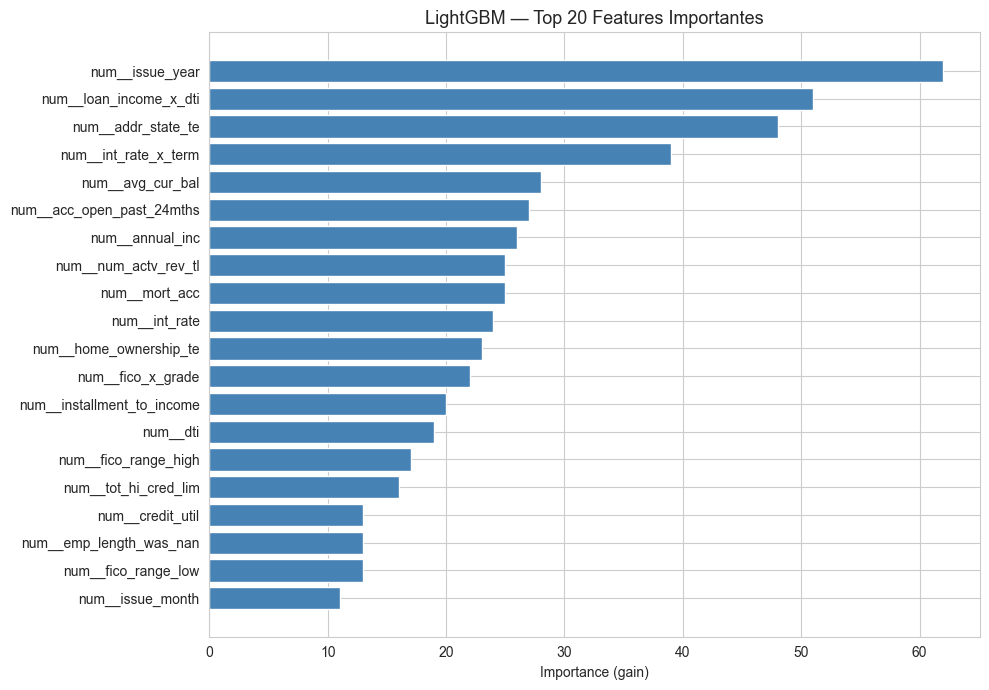

In [10]:
# Feature Importance LightGBM
feat_names = preprocessor.get_feature_names_out() if hasattr(preprocessor, 'get_feature_names_out') else [f'f{i}' for i in range(X_train_t.shape[1])]
imp_df = pd.DataFrame({'feature': feat_names, 'importance': lgbm_model.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='steelblue', edgecolor='white')
ax.set_title('LightGBM — Top 20 Features Importantes', fontsize=13)
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.savefig(f'{PROCESSED}/09_lgbm_feature_importance.png', dpi=130)
plt.show()

## 4. CatBoost ★ (optimal pour les variables catégorielles)

In [11]:
print('⏳ CatBoost ...')
cat_model = CatBoostClassifier(
    iterations        = 1000,
    learning_rate     = 0.05,
    depth             = 8,
    l2_leaf_reg       = 3,
    class_weights     = {0: 1, 1: (y_train == 0).sum() / (y_train == 1).sum()},
    eval_metric       = 'AUC',
    early_stopping_rounds = 50,
    random_seed       = 42,
    verbose           = 100,
    task_type         = 'GPU' if USE_GPU else 'CPU',
)
cat_model.fit(
    X_train_t, y_train,
    eval_set = (X_test_t, y_test),
)

y_proba_cat = cat_model.predict_proba(X_test_t)[:, 1]
y_pred_cat  = cat_model.predict(X_test_t)

results['CatBoost'] = {
    'AUC-ROC' : roc_auc_score(y_test, y_proba_cat),
    'AUC-PR'  : average_precision_score(y_test, y_proba_cat),
    'F1'      : f1_score(y_test, y_pred_cat),
    'Brier'   : brier_score_loss(y_test, y_proba_cat),
    'Temps(s)': 0,
    'model'   : cat_model,
    'y_proba' : y_proba_cat,
}
m = results['CatBoost']
print(f'\n  [CatBoost]  AUC-ROC={m["AUC-ROC"]:.4f}  AUC-PR={m["AUC-PR"]:.4f}  F1={m["F1"]:.4f}  Brier={m["Brier"]:.4f}')

⏳ CatBoost ...


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7037908	best: 0.7037908 (0)	total: 180ms	remaining: 2m 59s
100:	test: 0.7313060	best: 0.7313060 (100)	total: 2.78s	remaining: 24.8s
200:	test: 0.7362713	best: 0.7362713 (200)	total: 5.25s	remaining: 20.9s
300:	test: 0.7385545	best: 0.7385545 (300)	total: 7.81s	remaining: 18.1s
400:	test: 0.7401054	best: 0.7401054 (400)	total: 10.3s	remaining: 15.4s
500:	test: 0.7410392	best: 0.7410392 (500)	total: 12.8s	remaining: 12.7s
600:	test: 0.7416615	best: 0.7416615 (600)	total: 15.2s	remaining: 10.1s
700:	test: 0.7420847	best: 0.7420847 (700)	total: 17.7s	remaining: 7.56s
800:	test: 0.7424844	best: 0.7424844 (800)	total: 20.2s	remaining: 5.01s
900:	test: 0.7427236	best: 0.7427236 (900)	total: 22.6s	remaining: 2.48s
999:	test: 0.7429973	best: 0.7429973 (999)	total: 25.1s	remaining: 0us
bestTest = 0.7429973483
bestIteration = 999

  [CatBoost]  AUC-ROC=0.7430  AUC-PR=0.4243  F1=0.4544  Brier=0.2038


## 5. Random Forest (base du Stacking)

In [12]:
print('⏳ Random Forest ...')
rf = RandomForestClassifier(
    n_estimators    = 300,
    max_depth       = 20,
    min_samples_leaf= 20,
    class_weight    = 'balanced',
    n_jobs          = -1,
    random_state    = 42,
)
evaluate_model('Random Forest', rf, X_train_t, y_train, X_test_t, y_test)

⏳ Random Forest ...
  [Random Forest                 ]  AUC-ROC=0.7270  AUC-PR=0.3994  F1=0.4408  Brier=0.1889  (330s)


{'AUC-ROC': 0.7269776453617671,
 'AUC-PR': 0.3993691687866088,
 'F1': 0.440766060046056,
 'Brier': 0.18886001841842645,
 'Temps(s)': 330.3,
 'model': RandomForestClassifier(class_weight='balanced', max_depth=20,
                        min_samples_leaf=20, n_estimators=300, n_jobs=-1,
                        random_state=42),
 'y_proba': array([0.29956629, 0.39446524, 0.19251701, ..., 0.51774191, 0.63661674,
        0.23147863], shape=(269062,))}

## 6. Stacking Ensemble ★ (méta-apprentissage — hors cours)

**Principe :**
- **Niveau 0 (estimateurs de base)** : LightGBM + Random Forest + Régression Logistique
- **Niveau 1 (méta-modèle)** : Régression Logistique apprend à combiner leurs prédictions
- Utilisation de `cv=5` : les prédictions du niveau 0 sont générées **hors-fold** pour éviter le leakage

**Pourquoi ça marche ?** Chaque modèle capte des patterns différents ; le méta-modèle apprend à les peser intelligemment.

In [13]:
print('⏳ Stacking Ensemble (LightGBM + RF + LR → méta-LR) ...')

# Estimateurs de base (pré-entraînés réutilisés pour gagner du temps)
estimators = [
    ('lgbm', lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        random_state=42, verbose=-1, **LGBM_GPU_PARAMS
    )),
    ('rf', RandomForestClassifier(
        n_estimators=200, max_depth=15, class_weight='balanced',
        n_jobs=-1, random_state=42
    )),
    ('lr', LogisticRegression(
        max_iter=500, class_weight='balanced', C=0.1, n_jobs=-1, random_state=42
    )),
]

stacking = StackingClassifier(
    estimators       = estimators,
    final_estimator  = LogisticRegression(max_iter=500, C=1.0, random_state=42),
    cv               = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method     = 'predict_proba',
    passthrough      = False,
    n_jobs           = -1,
)

evaluate_model('Stacking (LGBM+RF+LR → LR)', stacking, X_train_t, y_train, X_test_t, y_test)

⏳ Stacking Ensemble (LightGBM + RF + LR → méta-LR) ...
  [Stacking (LGBM+RF+LR → LR)    ]  AUC-ROC=0.7417  AUC-PR=0.4220  F1=0.1978  Brier=0.1398  (1828s)


{'AUC-ROC': 0.7416877657890643,
 'AUC-PR': 0.4219749519943164,
 'F1': 0.1977943571528284,
 'Brier': 0.13979755313025607,
 'Temps(s)': 1827.7,
 'model': StackingClassifier(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                    estimators=[('lgbm',
                                 LGBMClassifier(device='gpu', gpu_device_id=0,
                                                gpu_platform_id=0,
                                                learning_rate=0.05,
                                                n_estimators=500, n_jobs=-1,
                                                num_leaves=63, random_state=42,
                                                scale_pos_weight=np.float64(4.00936945826565),
                                                verbose=-1)),
                                ('rf',
                                 RandomForestClassifier(class_weight='balanced',
                                                        max_depth=15,
       

## 7. Calibration des probabilités ★ (hors cours)

**Pourquoi calibrer ?**  
Un modèle peut avoir un excellent AUC tout en ayant des probabilités mal calibrées.  
Ex : LightGBM prédit 0.3 pour un client qui a en réalité 45% de chance de défaut.  
Les banques ont besoin de **vraies probabilités (PD)** pour l'IFRS 9 (provisionnement).  

**Méthodes :**
- **Platt Scaling** : régression sigmoïde — fonctionne bien si la distribution des scores est proche d'une gaussienne
- **Isotonic Regression** : monotone non-paramétrique — plus flexible, nécessite plus de données

In [16]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

print('⏳ Calibration de LightGBM ...')

# ── 1. Vérifier que le modèle est déjà entraîné ──
# (important pour cv=None)
lgbm_model.fit(X_train_t, y_train)

# ── 2. Split du test set (calibration / validation) ──
split = len(X_test_t) // 2

X_calib = X_test_t[:split]
y_calib = y_test.iloc[:split]

X_final = X_test_t[split:]
y_final = y_test.iloc[split:]

# ── 3. Calibration (nouvelle méthode remplace cv='prefit') ──
lgbm_platt = CalibratedClassifierCV(
    estimator=lgbm_model,
    method='sigmoid',   # Platt scaling
    cv=None             # remplace 'prefit'
)
lgbm_platt.fit(X_calib, y_calib)

lgbm_isotonic = CalibratedClassifierCV(
    estimator=lgbm_model,
    method='isotonic',
    cv=None
)
lgbm_isotonic.fit(X_calib, y_calib)

# ── 4. Évaluation ──
proba_raw      = lgbm_model.predict_proba(X_final)[:, 1]
proba_platt    = lgbm_platt.predict_proba(X_final)[:, 1]
proba_isotonic = lgbm_isotonic.predict_proba(X_final)[:, 1]

print(f'  Brier Score brut       : {brier_score_loss(y_final, proba_raw):.4f}')
print(f'  Brier Score Platt      : {brier_score_loss(y_final, proba_platt):.4f}')
print(f'  Brier Score Isotonic   : {brier_score_loss(y_final, proba_isotonic):.4f}')

⏳ Calibration de LightGBM ...
  Brier Score brut       : 0.1971
  Brier Score Platt      : 0.1427
  Brier Score Isotonic   : 0.1426


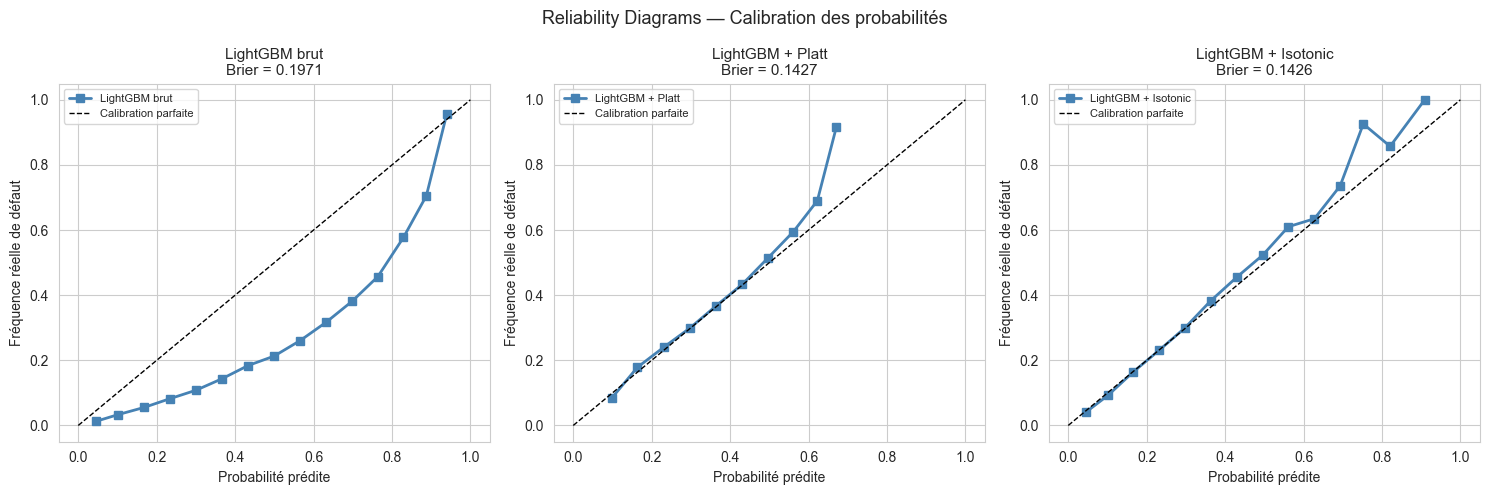

In [19]:
# Reliability Diagrams (Calibration Curves)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (proba, label) in zip(axes, [
    (proba_raw,      'LightGBM brut'),
    (proba_platt,    'LightGBM + Platt'),
    (proba_isotonic, 'LightGBM + Isotonic'),
]):
    frac_pos, mean_pred = calibration_curve(y_final, proba, n_bins=15, strategy='uniform')
    ax.plot(mean_pred, frac_pos, 's-', label=label, color='steelblue', lw=2)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Calibration parfaite')
    brier = brier_score_loss(y_final, proba)
    ax.set_title(f'{label}\nBrier = {brier:.4f}', fontsize=11)
    ax.set_xlabel('Probabilité prédite')
    ax.set_ylabel('Fréquence réelle de défaut')
    ax.legend(fontsize=8)

plt.suptitle('Reliability Diagrams — Calibration des probabilités', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PROCESSED}/10_calibration_curves.png', dpi=130)
plt.show()

In [21]:
# Ajout des modèles calibrés au tableau
y_cal = y_final
results['LightGBM + Platt'] = {
    'AUC-ROC'  : roc_auc_score(y_cal, proba_platt),
    'AUC-PR'   : average_precision_score(y_cal, proba_platt),
    'F1'       : f1_score(y_cal, (proba_platt > 0.5).astype(int)),
    'Brier'    : brier_score_loss(y_cal, proba_platt),
    'Temps(s)' : 0,
    'model'    : lgbm_platt,
    'y_proba'  : proba_platt,
}
results['LightGBM + Isotonic'] = {
    'AUC-ROC'  : roc_auc_score(y_cal, proba_isotonic),
    'AUC-PR'   : average_precision_score(y_cal, proba_isotonic),
    'F1'       : f1_score(y_cal, (proba_isotonic > 0.5).astype(int)),
    'Brier'    : brier_score_loss(y_cal, proba_isotonic),
    'Temps(s)' : 0,
    'model'    : lgbm_isotonic,
    'y_proba'  : proba_isotonic,
}
print('✅ Modèles calibrés ajoutés')

✅ Modèles calibrés ajoutés


## 8. Tableau comparatif & sélection du meilleur modèle

In [22]:
# Tableau de comparaison
exclude = ['model', 'y_proba']
compare_df = pd.DataFrame({
    name: {k: v for k, v in m.items() if k not in exclude}
    for name, m in results.items()
}).T.sort_values('AUC-ROC', ascending=False)

compare_df[['AUC-ROC','AUC-PR','F1','Brier','Temps(s)']] = compare_df[['AUC-ROC','AUC-PR','F1','Brier','Temps(s)']].astype(float)

print('\n' + '='*70)
print('   TABLEAU COMPARATIF — TOUS LES MODÈLES')
print('='*70)
print(compare_df[['AUC-ROC','AUC-PR','F1','Brier','Temps(s)']].to_string())
print('='*70)
print(f'\n🏆 Meilleur AUC-ROC : {compare_df["AUC-ROC"].idxmax()} ({compare_df["AUC-ROC"].max():.4f})')
print(f'🏆 Meilleur Brier   : {compare_df["Brier"].idxmin()} ({compare_df["Brier"].min():.4f})')


   TABLEAU COMPARATIF — TOUS LES MODÈLES
                                 AUC-ROC    AUC-PR        F1     Brier  Temps(s)
CatBoost                        0.742997  0.424316  0.454370  0.203799       0.0
Stacking (LGBM+RF+LR → LR)      0.741688  0.421975  0.197794  0.139798    1827.7
Random Forest                   0.726978  0.399369  0.440766  0.188860     330.3
LightGBM + Platt                0.725521  0.400923  0.153052  0.142745       0.0
LightGBM + Isotonic             0.725228  0.400430  0.130958  0.142606       0.0
LightGBM                        0.717678  0.384831  0.000000  0.154968      47.4
Logistic Regression (baseline)  0.700789  0.357460  0.422352  0.219467     199.8

🏆 Meilleur AUC-ROC : CatBoost (0.7430)
🏆 Meilleur Brier   : Stacking (LGBM+RF+LR → LR) (0.1398)


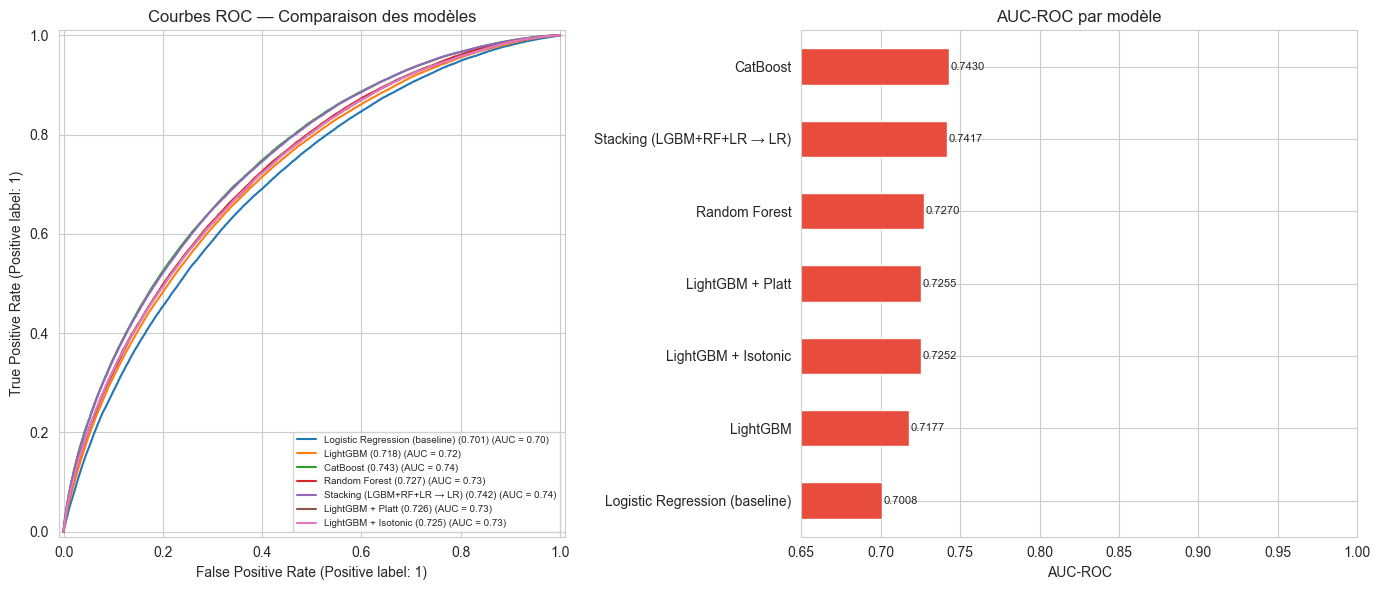

In [23]:
# Courbes ROC comparatives
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.tab10.colors
for i, (name, m) in enumerate(results.items()):
    if 'y_proba' in m:
        # Utilise le bon y_test selon le sous-ensemble
        y_true = y_cal if name in ['LightGBM + Platt', 'LightGBM + Isotonic'] else y_test
        RocCurveDisplay.from_predictions(
            y_true, m['y_proba'], name=f"{name} ({m['AUC-ROC']:.3f})",
            ax=ax1, color=colors[i % len(colors)]
        )

ax1.set_title('Courbes ROC — Comparaison des modèles', fontsize=12)
ax1.legend(fontsize=7, loc='lower right')

# Barplot AUC-ROC
compare_df['AUC-ROC'].sort_values().plot(
    kind='barh', ax=ax2, color=['#e74c3c' if v < 0.75 else '#f39c12' if v < 0.80 else '#2ecc71' for v in compare_df['AUC-ROC'].sort_values()],
    edgecolor='white'
)
ax2.set_xlim(0.65, 1.0)
ax2.set_title('AUC-ROC par modèle', fontsize=12)
ax2.set_xlabel('AUC-ROC')
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.4f}', (p.get_width() + 0.001, p.get_y() + p.get_height()/2), va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{PROCESSED}/11_roc_comparison.png', dpi=130)
plt.show()

In [24]:
# Sauvegarde du meilleur modèle
best_name  = compare_df['AUC-ROC'].idxmax()
best_model = results[best_name]['model']

joblib.dump(best_model,  f'{MODELS}/best_classifier.pkl')
joblib.dump(lgbm_model,  f'{MODELS}/lgbm_model.pkl')
joblib.dump(lgbm_platt,  f'{MODELS}/lgbm_calibrated.pkl')
joblib.dump(stacking,    f'{MODELS}/stacking_model.pkl')

compare_df.drop(columns=['model','y_proba'], errors='ignore').to_csv(f'{MODELS}/classification_results.csv')

print(f'✅ Meilleur modèle sauvegardé : {best_name}')
print(f'✅ Fichiers dans {MODELS}/')
print('\n→ Prochain : 05_optuna.ipynb')

✅ Meilleur modèle sauvegardé : CatBoost
✅ Fichiers dans ../data/models/

→ Prochain : 05_optuna.ipynb
